# Uso de `manifest_utils.py`

Ejemplo minimo de como leer una muestra de `d04_transformed_data/` (la data
final, ya limpia + suavizada + normalizada) usando `manifest.csv` para saber
su region valida (`valid_length`), sin necesidad de indexar los `.npy` a mano.

Caso de ejemplo: movimiento 2, muestra 98, canal `f1`.

In [1]:
import os
import sys

import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))  # utils/ vive en la raiz del repo
from utils import manifest_utils as mu

plt.rcParams["figure.dpi"] = 100

MOVEMENT_ID = 2
SAMPLE_INDEX = 98
SENSOR_ID = 1       # f1 vive en sensorID=2 (glove/flexion)
CHANNEL = "pitch1"

manifest = mu.load_manifest()
print(f"{len(manifest)} muestras en el manifest")
manifest.head()

3884 muestras en el manifest


,movement_id,movement_name,limb,sample_index,orig_index_in_raw,valid_length_sensor1,valid_length_sensor2
0,0,Bobath handshake,upper,0,0,880,880
1,0,Bobath handshake,upper,1,1,880,880
2,0,Bobath handshake,upper,2,2,880,880
3,0,Bobath handshake,upper,3,3,777,880
4,0,Bobath handshake,upper,4,4,797,880


## Fila del manifest para esta muestra

In [2]:
row = mu.get_manifest_row(manifest, MOVEMENT_ID, SAMPLE_INDEX)
row

movement_id                                            2
movement_name           Bobath forward flexion/extension
limb                                               upper
sample_index                                          98
orig_index_in_raw                                    144
valid_length_sensor1                                 544
valid_length_sensor2                                 561
Name: 468, dtype: object

## Señal de un canal, recortada a su region valida

`get_sample_channel` regresa la señal ya recortada con `valid_length_sensor{SENSOR_ID}`
(el resto de las 880 posiciones es padding, no señal real).

In [3]:
signal, valid_len, channel_name = mu.get_sample_channel(
    manifest, MOVEMENT_ID, SAMPLE_INDEX, SENSOR_ID, CHANNEL
)
print(f"canal={channel_name}  valid_length={valid_len}  timesteps devueltos={len(signal)}")
signal[:10]

canal=pitch1  valid_length=544  timesteps devueltos=544


array([-1.03810068, -1.0045561 , -0.97134965, -0.93802204, -0.9047079 ,
       -0.86918666, -0.79696675, -0.72380627, -0.64804764, -0.56817593])

## Graficar un canal

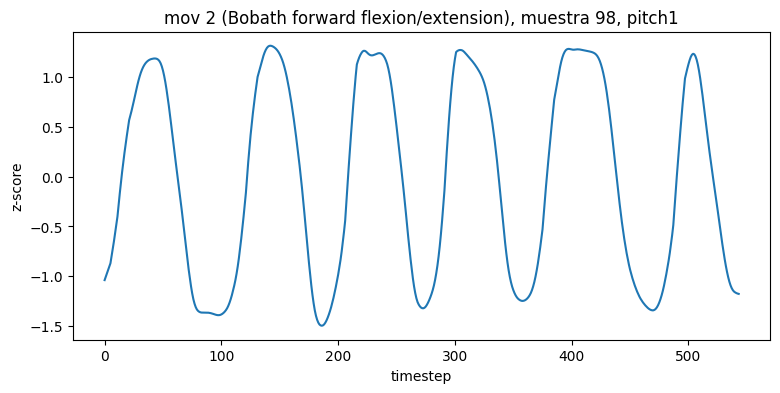

In [4]:
mu.plot_sample_channel(manifest, MOVEMENT_ID, SAMPLE_INDEX, SENSOR_ID, CHANNEL)
plt.show()

## Graficar los 6 canales del sensor a la vez

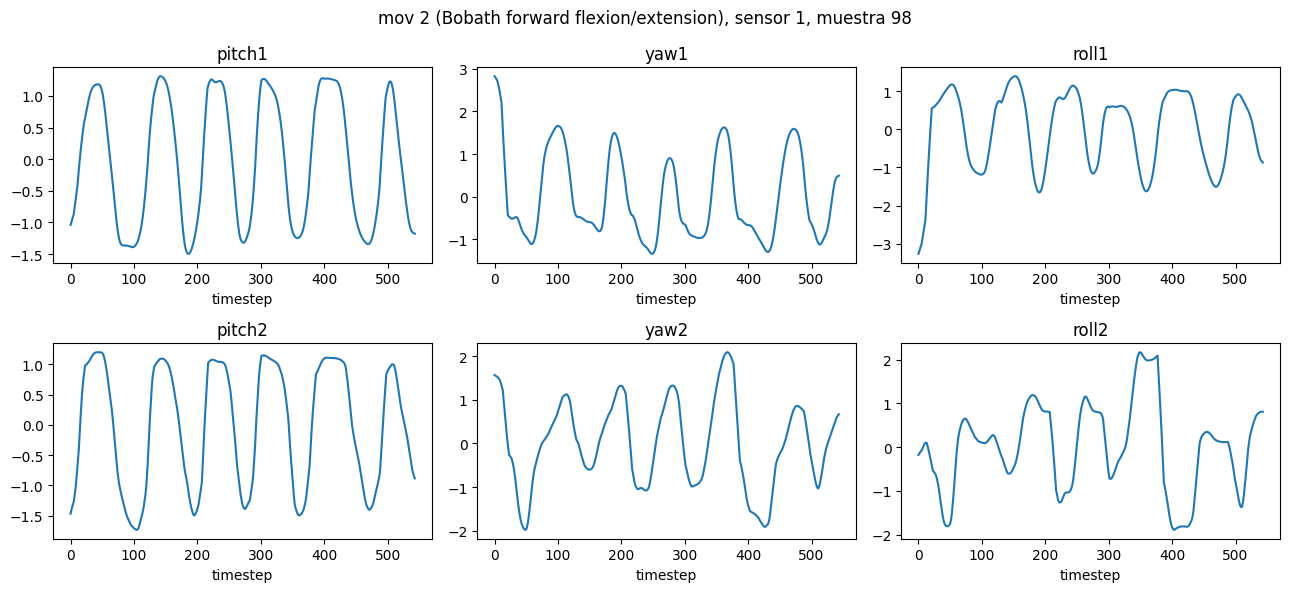

In [5]:
mu.plot_sample_all_channels(manifest, MOVEMENT_ID, SAMPLE_INDEX, SENSOR_ID)
plt.show()